In [23]:
%load_ext autoreload
%autoreload 2

import sys, importlib, shutil
from pathlib import Path
from qiskit.visualization import plot_histogram
import numpy as np

workspace_root = str(Path.cwd().parent)
if workspace_root not in sys.path:
    sys.path.insert(0, workspace_root)

# Clear stale bytecode cache
shutil.rmtree(Path(workspace_root) / 'utils/__pycache__', ignore_errors=True)

# import utils.experiment
# importlib.reload(utils.experiment)

# from utils.experiment import Experiment

# a = 1  # decay constant
# n_qubits = 8
# max_range = 4

# exp = Experiment(allow_measurement, optimize_t_gates)
# exp.run_single_s1_1d_overlap_integral(n_qubits, a, max_range, 22)

# Force-reload modules so kernel picks up any source changes
import utils.arithmetic, utils.sto_1s_1d, utils.integrals, utils.simulation_excutor, utils.sample_interpreter
import utils.noisy_sampler_executor, utils.noisy_estimator_executor, utils.resource_estimator
importlib.reload(utils.arithmetic)
importlib.reload(utils.sto_1s_1d)
importlib.reload(utils.integrals)
importlib.reload(utils.simulation_excutor)
importlib.reload(utils.sample_interpreter)
importlib.reload(utils.noisy_sampler_executor)
importlib.reload(utils.noisy_estimator_executor)
importlib.reload(utils.resource_estimator)

from utils.simulation_excutor import SimulationExecutor
from utils.sample_interpreter import SampleInterpreter
from utils.noisy_sampler_executor import NoisySamplerExecutor
from utils.noisy_estimator_executor import NoisyEstimatorExecutor
from utils.resource_estimator import ResourceEstimator

allow_measurement=True
optimize_t_gates=True

simulation_executor = SimulationExecutor()
sample_interpreter = SampleInterpreter()
noisy_simlutation_executor = NoisySamplerExecutor(enable_dd=(not allow_measurement), enable_twirling=True, enable_m3=True)
noisy_estimator_executor = NoisyEstimatorExecutor(enable_dd=(not allow_measurement),
                                                  enable_twirling=True,
                                                  enable_measure_mitigation=True,
                                                  enable_zne=True,
                                                  zne_noise_factors=[1, 3, 5, 7])
resource_estimator = ResourceEstimator()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


qubit count=8
center2=150


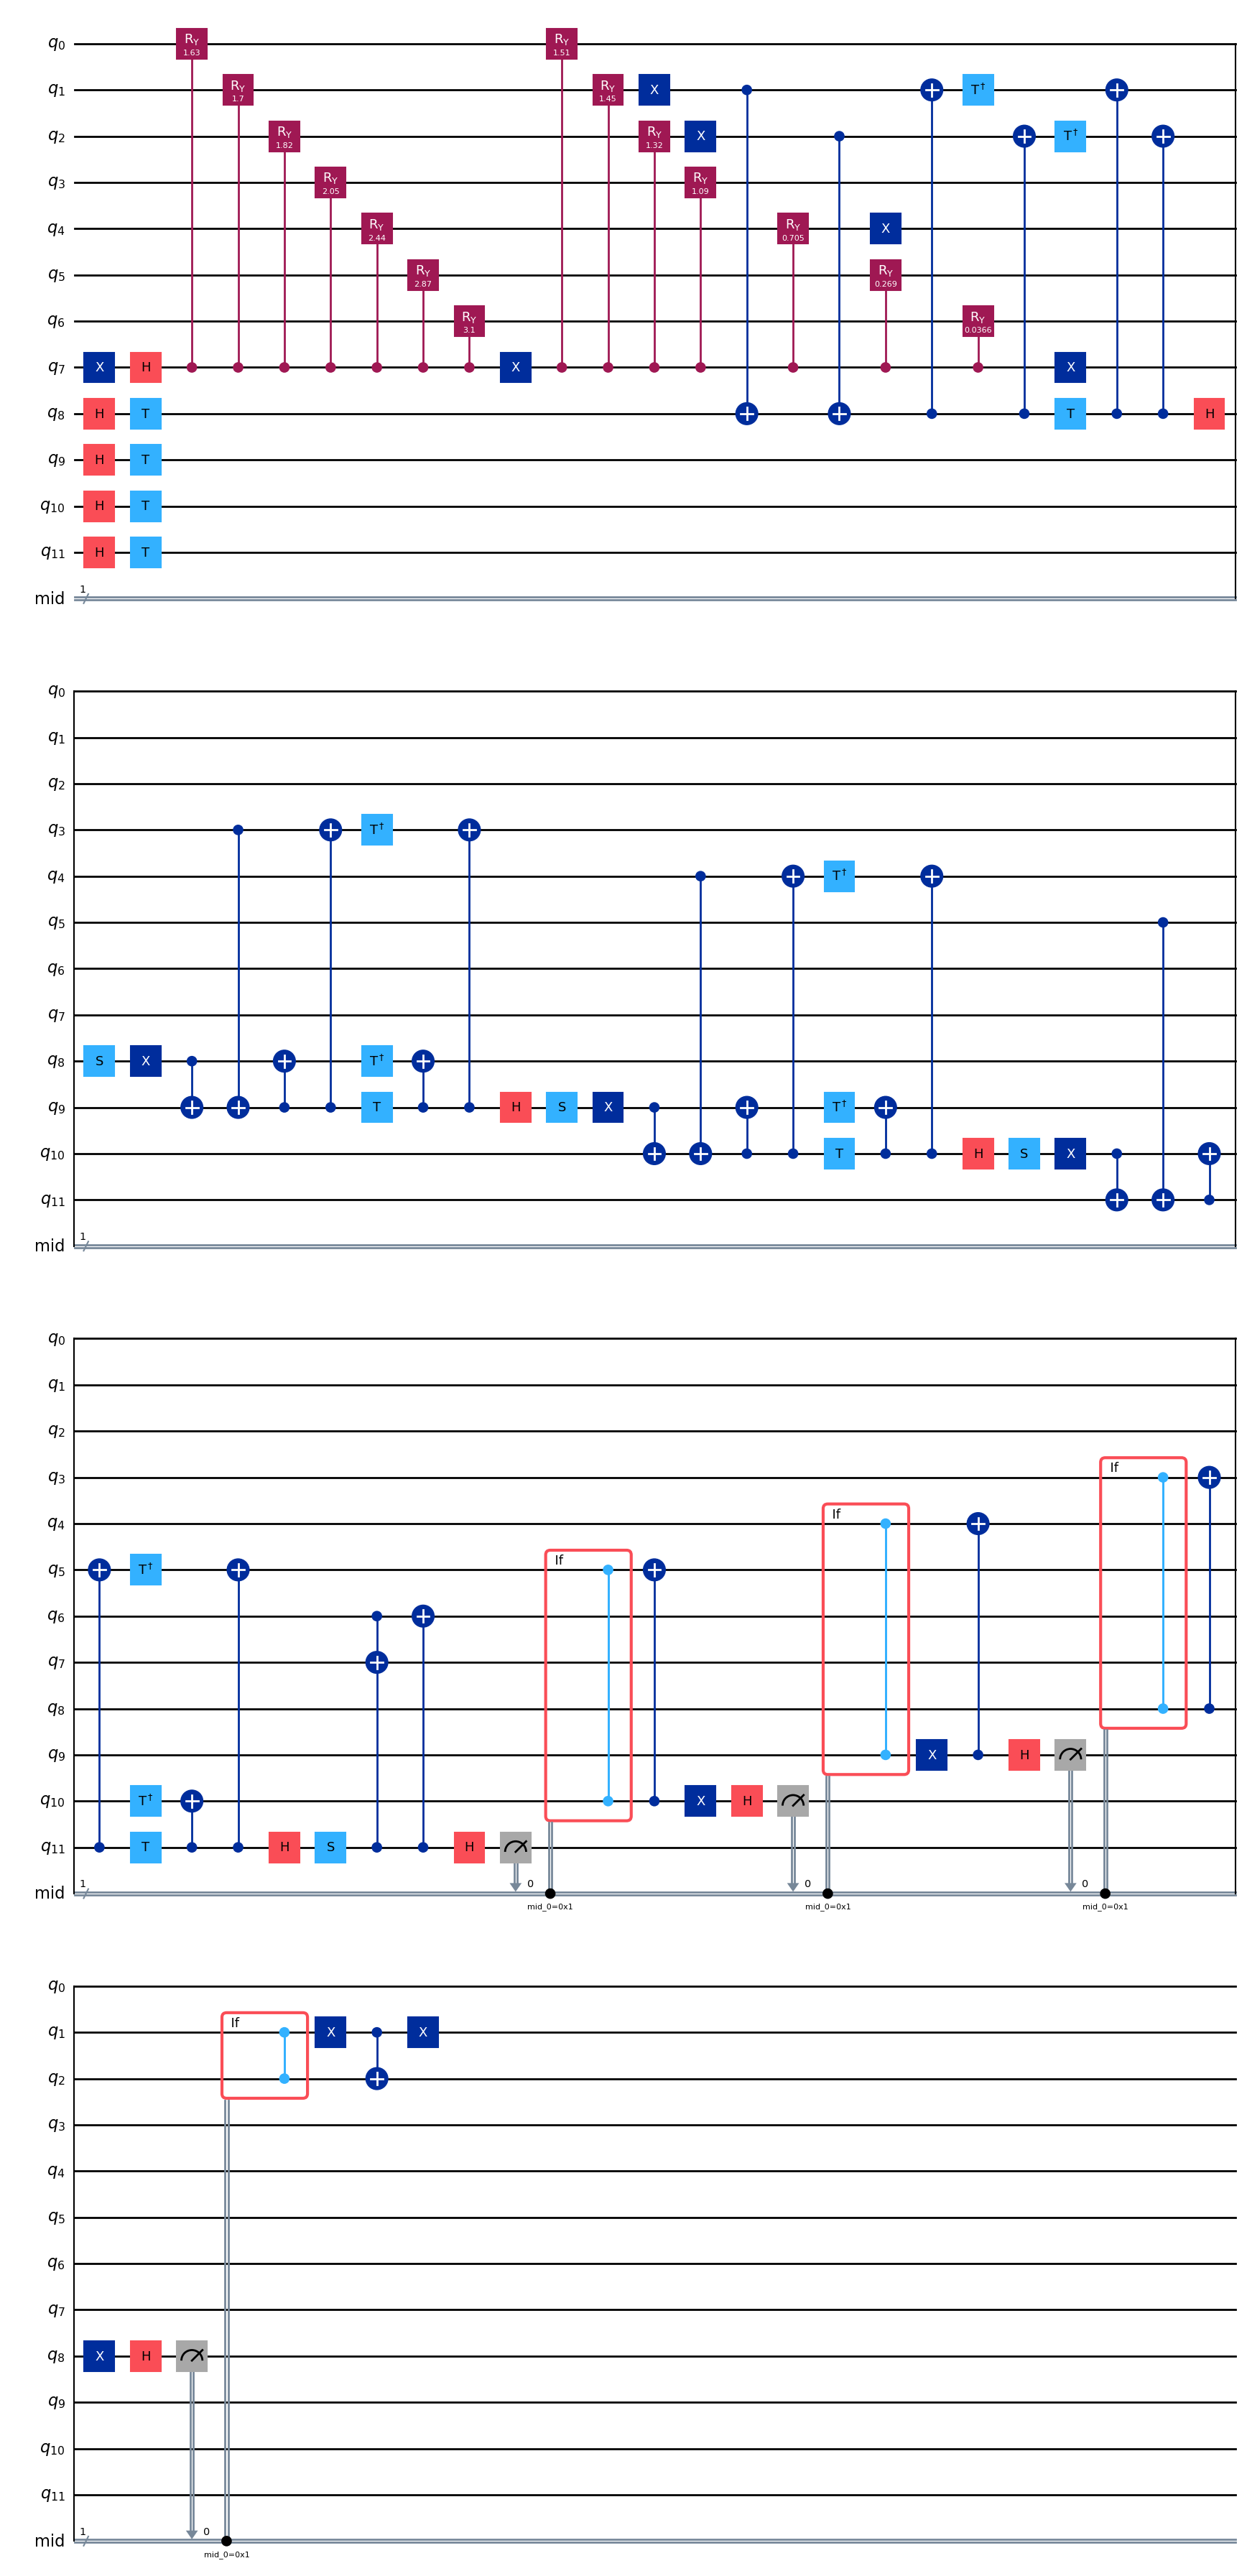

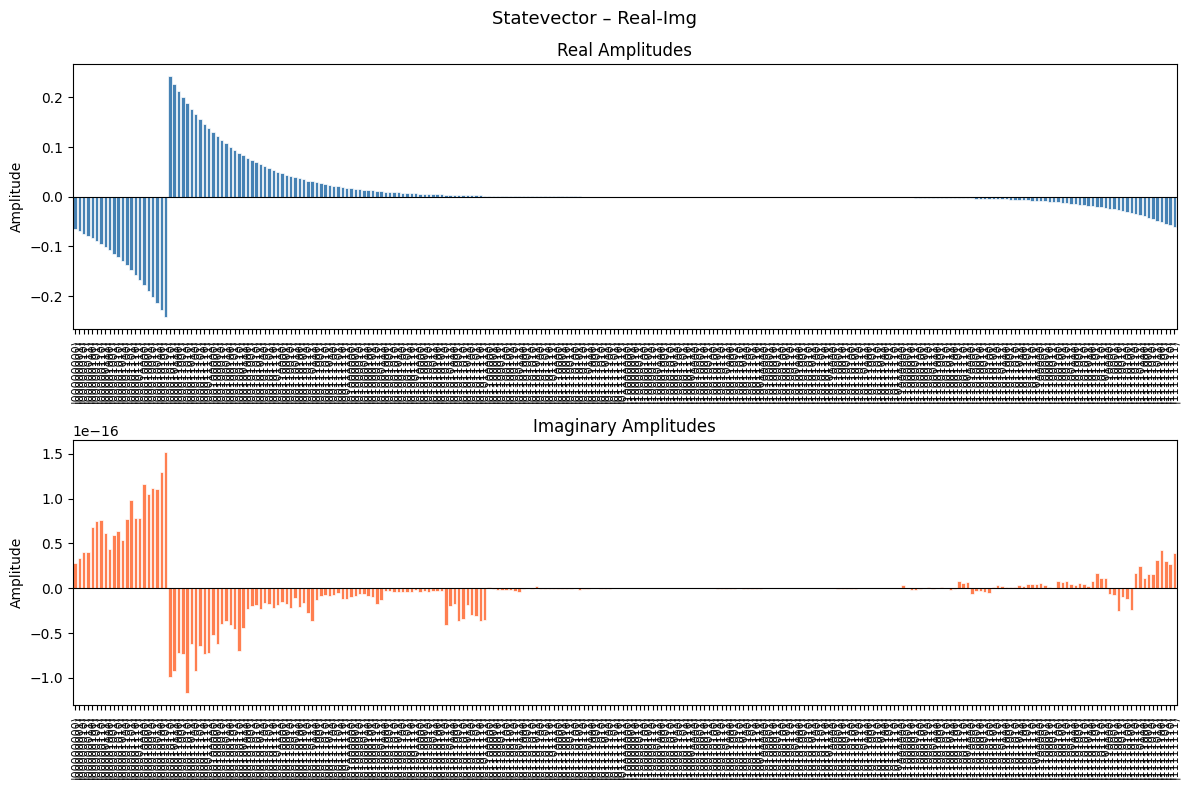

In [24]:


a = 1  # decay constant
n_qubits = 8
max_range = 16
center_distance = 1.4

scale = (2 ** n_qubits) / max_range
scaled_center_distance = round(center_distance * scale)
scaled_a = a / scale

used_center_distance = scaled_center_distance / scale
exact_result = (1 + used_center_distance) * np.exp(-used_center_distance)

center1 = 2 ** (n_qubits - 1)
center2 = 2 ** (n_qubits - 1) + scaled_center_distance

print(f"qubit count={n_qubits}")
print(f"center2={center2}")

from utils.sto_1s_1d import Sto1S
sto1s = Sto1S(allow_measurement, optimize_t_gates)

# Decaying exponential state: |ψ⟩ = N · Σ e^(-a·i) |i⟩  for i = 0 … 2^4-1

#qc = sto1s.get_sto_1s_1d_carthesian(n_qubits, scaled_a, 0)
qc = sto1s.get_sto_1s_1d_derivative_carthesian(n_qubits, scaled_a, 22)

display(qc.draw('mpl'))

# print(get_ancilla_amplitudes(qc, n_qubits))


data_amps = simulation_executor.get_data_amplitudes(qc, n_qubits)
fig = simulation_executor.plot_statevector_real_imag(data_amps, n_qubits)
# fig = simulation_executor.plot_statevector_modulus_phase(data_amps, n_qubits)

# shots = 10024
# counts = simulation_executor.sample_measurement_counts(qc, n_qubits, shots=shots)
# fig = sample_interpreter.plot_sampled_measurements(counts)
# # simulation_executor.print_statevector(data_amps, n_qubits)

analitical_zero_amplitude = 0.3478802527290194
analitical_zero_probability = 0.12102067023880642
sampled_zero_amplitude = 0.34208062504375664
sampled_zero_probability = 0.11701915403032721

Error vs continuous:  0.2584  (43.03 %)
Discretisation error: 0.2526  (42.07 %)
Shot noise:           0.0058  (1.67 %)


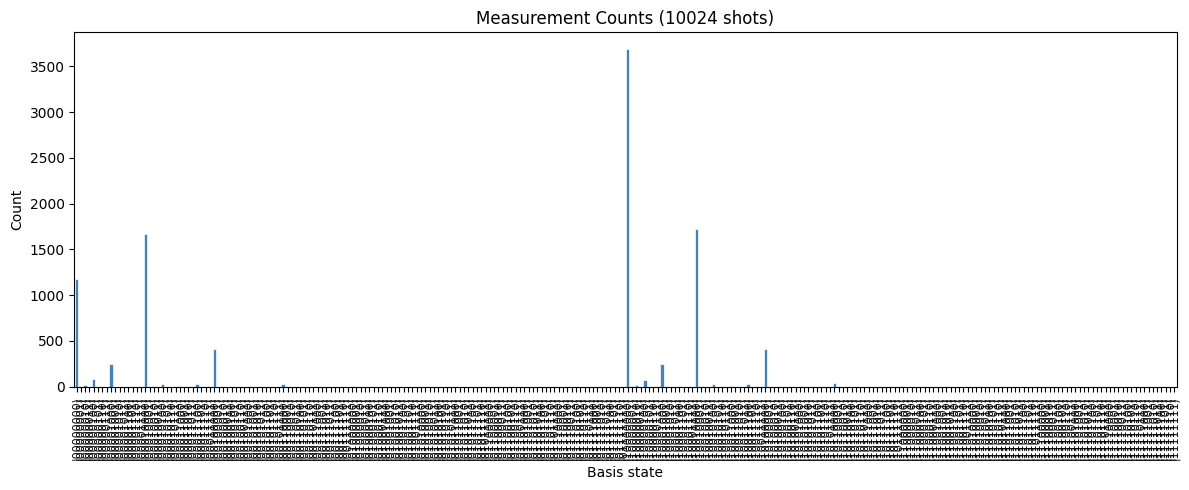

In [25]:
from utils.integrals import Integals

integrals = Integals(allow_measurement, optimize_t_gates)
qc = integrals.get_s1_1d_kinetic_derivative(n_qubits, scaled_a, scaled_center_distance)

# display(qc.draw('mpl'))
data_amps = simulation_executor.get_data_amplitudes(qc, n_qubits)
# fig = simulation_executor.plot_statevector_real_imag(data_amps, n_qubits)
# fig = simulation_executor.plot_statevector_modulus_phase(data_amps, n_qubits)

shots = 10024
counts = simulation_executor.sample_measurement_counts(qc, n_qubits, shots=shots)
fig = sample_interpreter.plot_sampled_measurements(counts)

analitical_zero_amplitude = simulation_executor.get_analytical_zero_amplitude(data_amps)
analitical_zero_probablity = simulation_executor.get_analytical_zero_probability(data_amps)
sampled_zero_amplitude = sample_interpreter.get_zero_amplitude(counts)
sampled_zero_probability = sample_interpreter.get_zero_probability(counts)

print(f"analitical_zero_amplitude = {analitical_zero_amplitude}")
print(f"analitical_zero_probability = {analitical_zero_probablity}")
print(f"sampled_zero_amplitude = {sampled_zero_amplitude}")
print(f"sampled_zero_probability = {sampled_zero_probability}")

sample_interpreter.print_errors(exact_result, sampled_zero_amplitude, analitical_zero_amplitude)

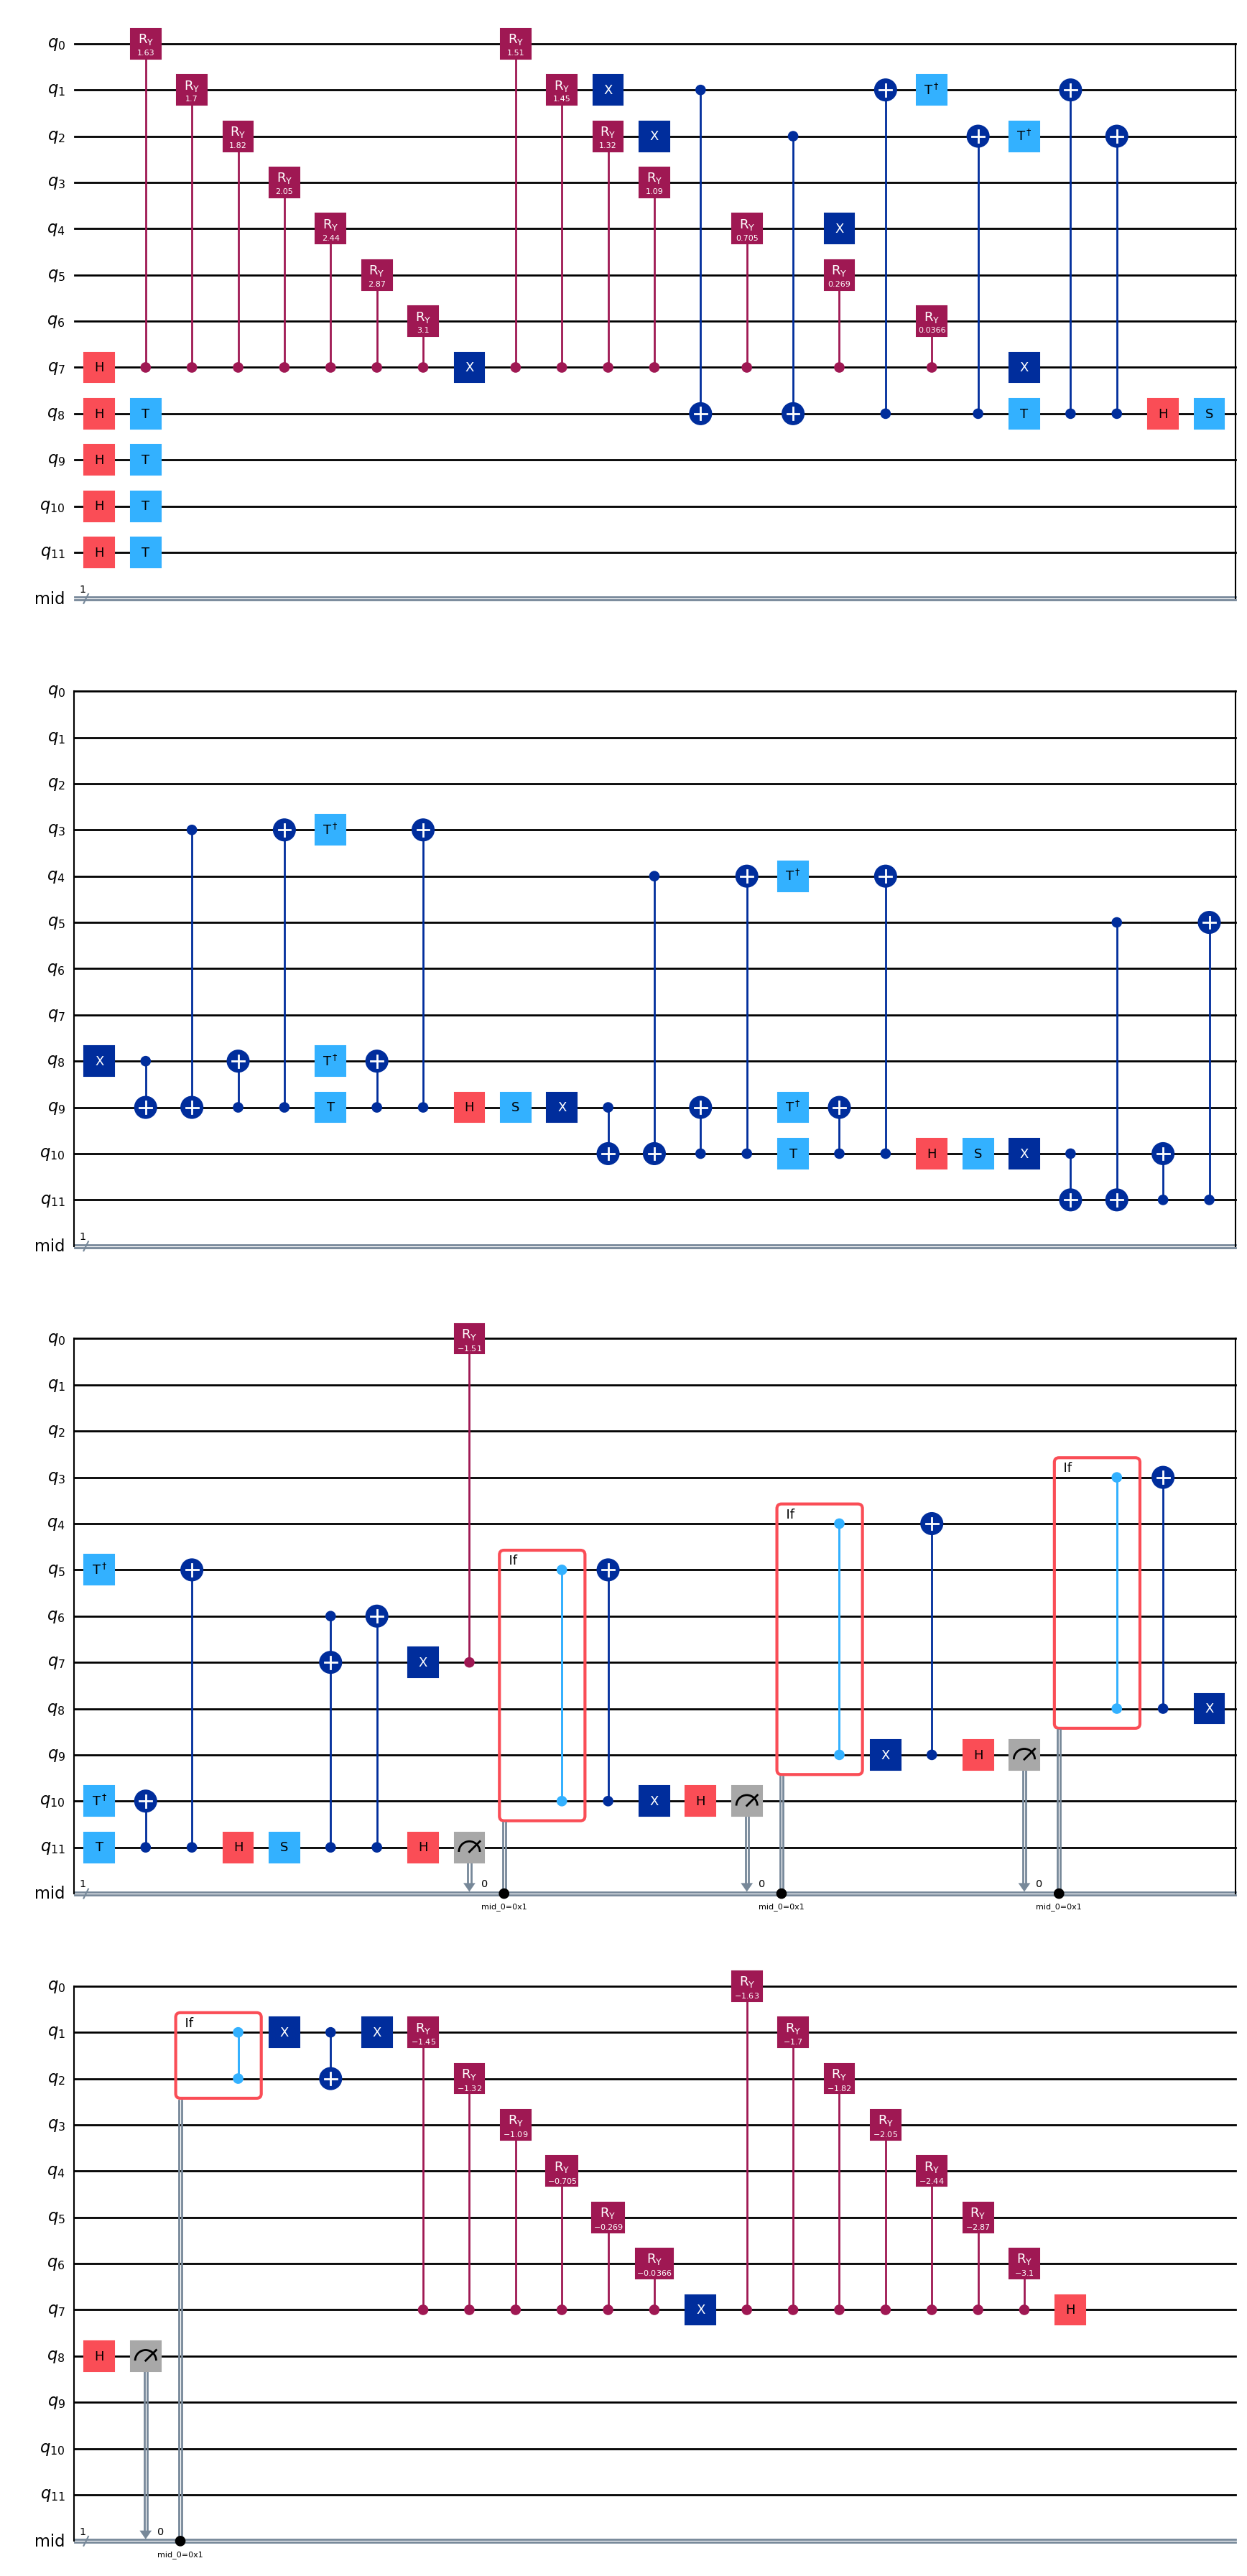

In [117]:
qc.draw('mpl')

  Qubits (transpiled)  : 127
  Depth                : 191
  Single-qubit gates   : 255  (rz + sx + x)
  Two-qubit gates (ecr): 48
  T gates (logical)    : 4
  All gate counts      : {'rz': 154, 'sx': 92, 'ecr': 48, 'x': 9, 'measure': 1, 'if_else': 1}


c:\Users\sorin\anaconda3\envs\qiskit21\Lib\site-packages\qiskit_ibm_runtime\fake_provider\local_service.py:274: UserWarning: Options {'twirling': {'enable_gates': True, 'enable_measure': True, 'num_randomizations': 32}} have no effect in local testing mode.
  warnings.warn(f"Options {options_copy} have no effect in local testing mode.")



noisy_sampled_zero_amplitude = 0.6449818572403365
noisy_sampled_zero_probability = 0.4160015961691939

Error vs continuous:  0.0908  (12.34 %)
Discretisation error: 0.0645  (8.76 %)
Shot noise:           0.1552  (19.40 %)


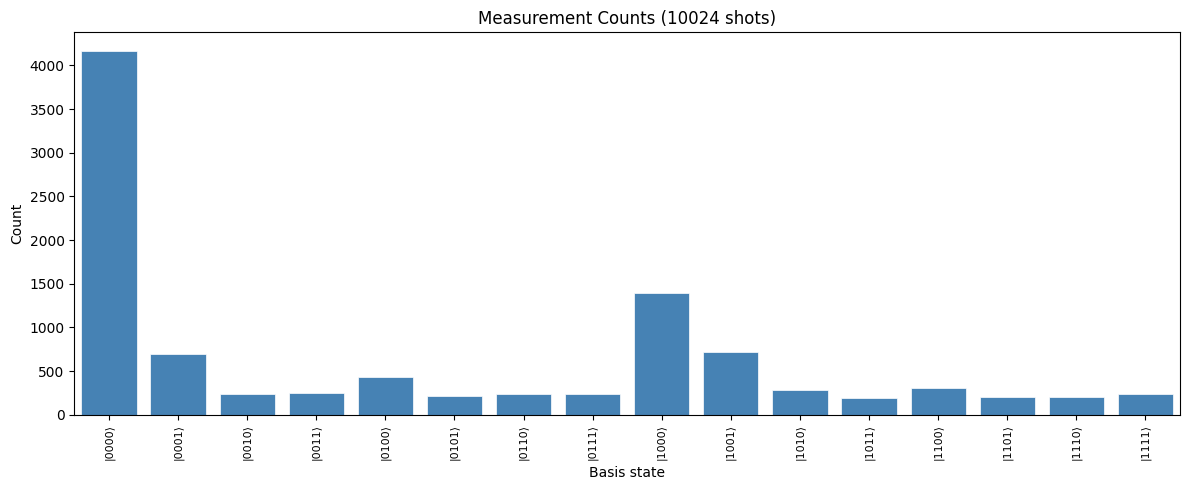

In [103]:
stats = resource_estimator.get_circuit_stats(qc)
stats.print()

counts = noisy_simlutation_executor.sample_measurement_counts(qc, n_qubits, shots=shots)
fig = sample_interpreter.plot_sampled_measurements(counts)
noisy_sampled_zero_amplitude = sample_interpreter.get_zero_amplitude(counts)
noisy_sampled_zero_probability = sample_interpreter.get_zero_probability(counts)
print()
print(f"noisy_sampled_zero_amplitude = {noisy_sampled_zero_amplitude}")
print(f"noisy_sampled_zero_probability = {noisy_sampled_zero_probability}")

sample_interpreter.print_errors(exact_result, noisy_sampled_zero_amplitude, analitical_zero_amplitude)

c:\Users\sorin\anaconda3\envs\qiskit21\Lib\site-packages\qiskit_ibm_runtime\fake_provider\local_service.py:274: UserWarning: Options {'twirling': {'enable_gates': True, 'enable_measure': True, 'num_randomizations': 32}} have no effect in local testing mode.
  warnings.warn(f"Options {options_copy} have no effect in local testing mode.")


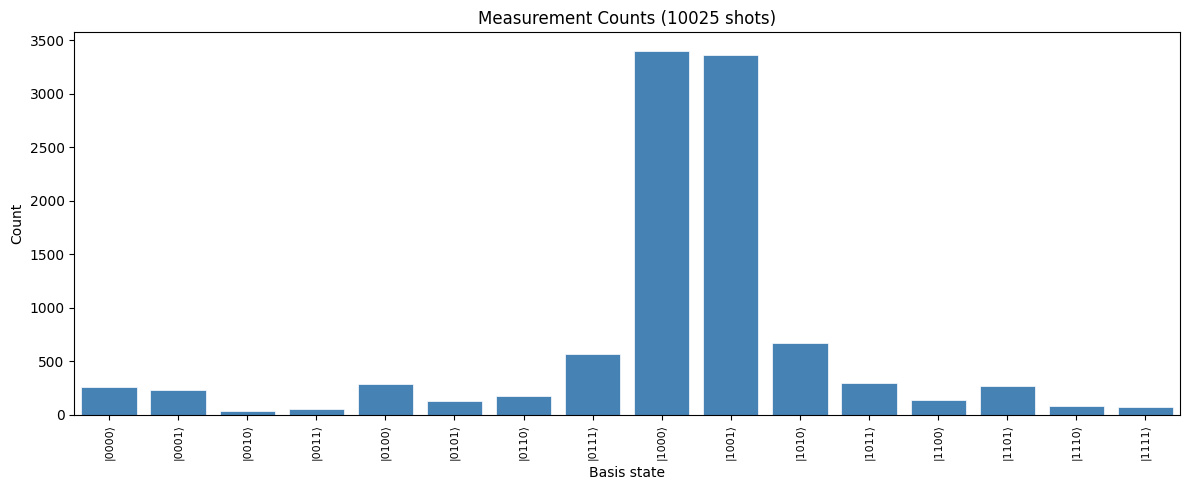

In [105]:
qc = sto1s.get_sto_1s_1d_carthesian(n_qubits, scaled_a, center1+scaled_center_distance)
counts = noisy_simlutation_executor.sample_measurement_counts(qc, n_qubits, shots=shots)
fig = sample_interpreter.plot_sampled_measurements(counts)

In [107]:
estimator_amplitude_of_zero, estimator_probability_of_zero = noisy_estimator_executor.get_amplitude_of_zero(qc, n_qubits, shots=shots)

print(f"estimator_probability_of_zero = {estimator_probability_of_zero}")
print(f"estimator_amplitude_of_zero = {estimator_amplitude_of_zero}")

sample_interpreter.print_errors(exact_result, estimator_amplitude_of_zero, analitical_zero_amplitude)

c:\Users\sorin\anaconda3\envs\qiskit21\Lib\site-packages\qiskit_ibm_runtime\fake_provider\local_service.py:274: UserWarning: Options {'resilience': {'measure_mitigation': True, 'zne_mitigation': True, 'zne': {'noise_factors': [1.0, 3.0, 5.0, 7.0], 'extrapolator': 'exponential'}}, 'twirling': {'enable_gates': True, 'enable_measure': True, 'num_randomizations': 32}} have no effect in local testing mode.
  warnings.warn(f"Options {options_copy} have no effect in local testing mode.")


estimator_probability_of_zero = 0.032422186751795694
estimator_amplitude_of_zero = 0.18006161931904227

Error vs continuous:  0.5557  (75.53 %)
Discretisation error: 0.0645  (8.76 %)
Shot noise:           0.6202  (77.50 %)


In [ ]:
# ── Overlap circuit:  O₂† · O₁ · |0⟩ ────────────────────────────────────────
# S = ⟨ψ₁|ψ₂⟩ = ⟨0|O₁†O₂|0⟩  ⟹  circuit = O₁† O₂ (or equivalently O₂† O₁)
# P(|0…0⟩) = |S|²   →   S = √P  (real, positive wavefunctions)

# center1 effective max is at index 127.5  → physical position 127.5 * dx = 7.96875
# center2 = 150: effective max at 149.5    → physical position 149.5 * dx = 9.34375
# separation d = (149.5 - 127.5) * dx = 22 * (1/16) = 1.375 a.u.  ≈ 1.4 a.u.

center2_overlap = 150
d_grid  = (149.5 - 127.5) * scale          # effective physical separation
S_cont  = (1 + a * d_grid) * np.exp(-a * d_grid)   # continuous benchmark

# qc_sto uses mid-circuit measurement-based uncompute and carries a 'mid'
# classical register.  sto_dagger is fully unitary (uses .inverse()).
qc_sto     = sto1s.get_sto_1s_1d_carthesian(n_qubits, a, max_range, center2_overlap)
qc_sto_dag = sto1s.get_sto_1s_1d_carthesian_dagger(n_qubits, a, max_range, center1)
n_ov_total = max(qc_sto.num_qubits, qc_sto_dag.num_qubits)
n_anc_ov   = n_ov_total - n_qubits

# Build the overlap circuit.  qc_sto carries a 'mid' classical register, so
# we add it explicitly and map clbits during compose.
mid_ov = ClassicalRegister(1, 'mid')
qc_overlap = QuantumCircuit(n_ov_total)
qc_overlap.add_register(mid_ov)
qc_overlap.compose(qc_sto,     qubits=list(range(qc_sto.num_qubits)),
                   clbits=[mid_ov[0]], inplace=True)
qc_overlap.compose(qc_sto_dag, qubits=list(range(qc_sto_dag.num_qubits)), inplace=True)

zero_key_ov = '0' * n_qubits

# ── Exact overlap via Aer statevector (ground truth) ──────────────────────────
# After mid-circuit measurements the ancilla qubits collapse to a definite
# classical state (not necessarily |0⟩), just as in cell 3.  We must use the
# same reshape trick: find the dominant ancilla block and extract the data-|0⟩
# amplitude from it.
qc_ov_sv = qc_overlap.copy()
qc_ov_sv.save_statevector()
sv_ov = np.array(sim.run(qc_ov_sv, shots=1).result().get_statevector())

if n_anc_ov > 0:
    sv_ov_blocks  = sv_ov.reshape(2**n_anc_ov, 2**n_qubits)
    block_norms   = np.sum(np.abs(sv_ov_blocks)**2, axis=1)
    anc_idx       = np.argmax(block_norms)
    S_exact = sv_ov_blocks[anc_idx, 0].real   # data |0…0⟩ in dominant ancilla block
    P_exact = abs(sv_ov_blocks[anc_idx, 0]) ** 2
else:
    S_exact = sv_ov[0].real
    P_exact = abs(sv_ov[0]) ** 2

print(f"Effective separation    d  = {d_grid:.4f} a.u.  (closest to 1.4 a.u.)")
print(f"Continuous benchmark    S  = {S_cont:.6f}")
print()
print(f"Exact (Aer statevector) amplitude  ⟨0|circuit|0⟩ = {S_exact:.6f}")
print(f"Exact (Aer statevector) |S|²       P(|0…0⟩)      = {P_exact:.6f}")
print(f"Exact S = √P                                      = {np.sqrt(P_exact):.6f}")
print()

# ── Sampler estimation via Aer shot-based simulation ─────────────────────────
# Add a dedicated 'meas_ov' register so we can extract just the data qubit bits
# from the space-separated multi-register bitstring Aer returns.
shots = 8192
qc_ov_sample = qc_overlap.copy()
meas_ov_reg = ClassicalRegister(n_qubits, 'meas_ov')
qc_ov_sample.add_register(meas_ov_reg)
qc_ov_sample.measure(list(range(n_qubits)), meas_ov_reg)

raw_ov = sim.run(qc_ov_sample, shots=shots).result().get_counts()

# Bitstring format: 'meas_ov_bits mid_bit'  ('meas_ov' added last → leftmost token)
zero_count = sum(c for bs, c in raw_ov.items() if bs.split()[0] == zero_key_ov)
p_zero_sampled = zero_count / shots
S_sampled = np.sqrt(p_zero_sampled)

print(f"Sampler ({shots} shots):")
print(f"  Counts for |{zero_key_ov}⟩  = {zero_count}")
print(f"  P(|0…0⟩)  = {p_zero_sampled:.6f}")
print(f"  S = √P    = {S_sampled:.6f}")
print()
print(f"Error vs continuous:  {abs(S_sampled - S_cont):.4f}  ({abs(S_sampled - S_cont)/S_cont*100:.2f} %)")
print(f"Discretisation error: {abs(S_exact  - S_cont):.4f}  ({abs(S_exact  - S_cont)/S_cont*100:.2f} %)")
print(f"Shot noise:           {abs(S_sampled - S_exact):.4f}  ({abs(S_sampled - S_exact)/S_exact*100:.2f} %)")

=== Logical circuit ===
Qubits              : 12
Depth               : 90
Gate counts         : {'cx': 29, 'cry': 28, 'x': 17, 'h': 14, 'measure': 12, 't': 8, 'tdg': 8, 's': 4, 'if_else': 4, 'ccx': 1}

=== After transpilation to IBM native gates (no connectivity constraint) ===
Depth               : 291
Gate counts         : {'rz': 223, 'sx': 106, 'ecr': 87, 'x': 61, 'measure': 12, 'if_else': 4}
2-qubit gates (ECR) : 87

=== Feasibility summary ===
ECR count           : 87
Est. fidelity       : (1 - 0.003)^87 = 0.7700
Verdict             : feasible ✓


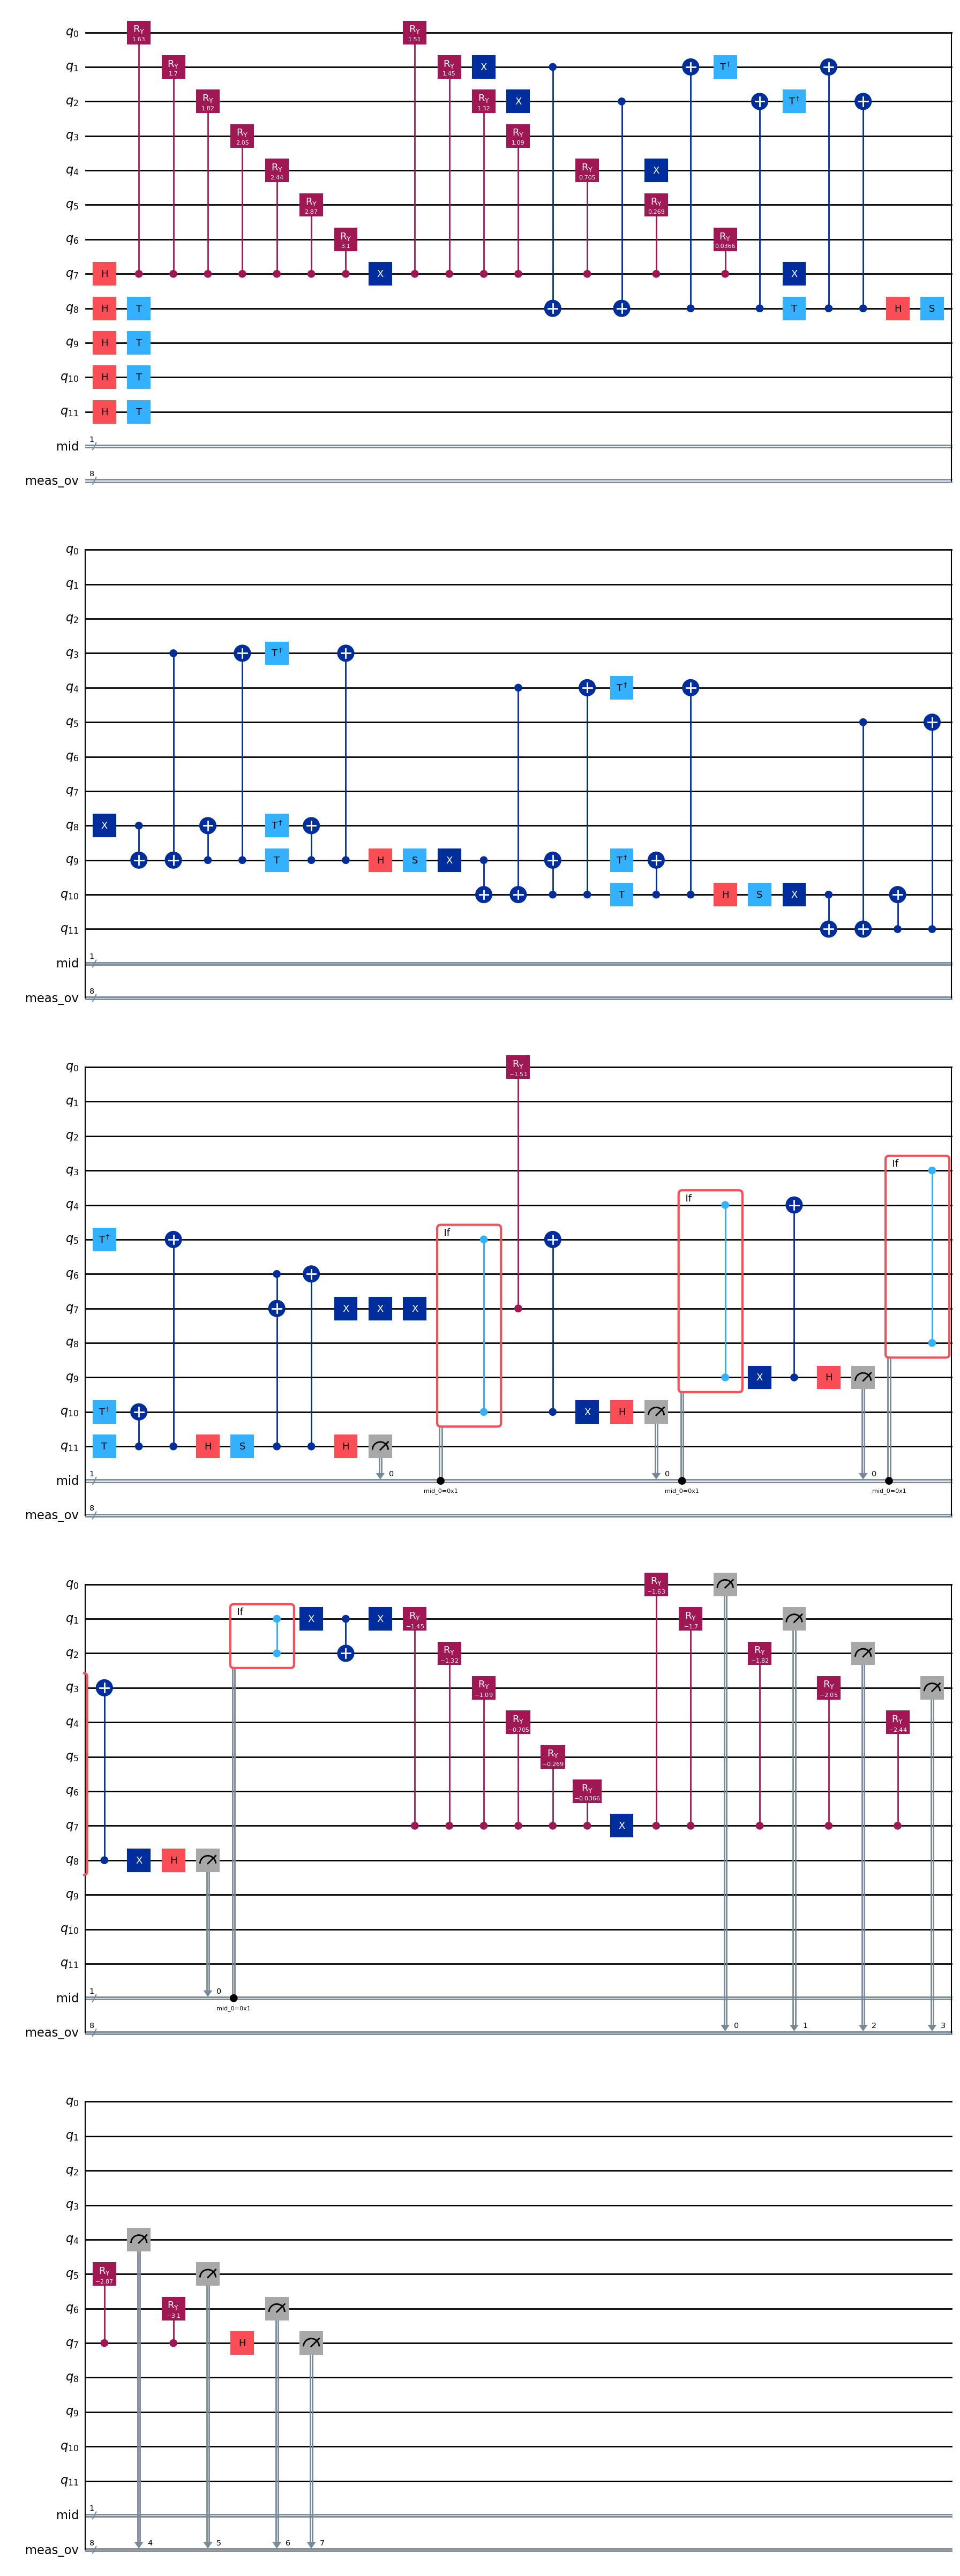

In [102]:
from qiskit.compiler import transpile

# ── Circuit complexity (logical) ───────────────────────────────────────────────

print("=== Logical circuit ===")
print(f"Qubits              : {qc_ov_sample.num_qubits}")
print(f"Depth               : {qc_ov_sample.depth()}")
print(f"Gate counts         : {dict(qc_ov_sample.count_ops())}")

# ── Transpile to IBM's native gate set (basis: ECR, RZ, SX, X) ────────────────
# Using 'ibm_torino' topology as a representative 133-qubit Heron r1 device.
# optimization_level=3 = most aggressive optimisation Qiskit can do.
qc_t = transpile(qc_ov_sample, basis_gates=['ecr', 'rz', 'sx', 'x'],
                 optimization_level=3, seed_transpiler=42)

two_q = {k: v for k, v in qc_t.count_ops().items() if k == 'ecr'}
print()
print("=== After transpilation to IBM native gates (no connectivity constraint) ===")
print(f"Depth               : {qc_t.depth()}")
print(f"Gate counts         : {dict(qc_t.count_ops())}")
print(f"2-qubit gates (ECR) : {two_q.get('ecr', 0)}")
print()
print("=== Feasibility summary ===")
ecr_count = two_q.get('ecr', 0)
# Typical IBM Heron r1 2Q gate error ~ 3e-3, T1/T2 ~ 100-300 us, gate time ~ 100ns
# Rule of thumb: circuit is viable if ecr_count * error_per_ecr << 1
error_per_ecr = 3e-3
expected_fidelity = (1 - error_per_ecr) ** ecr_count
print(f"ECR count           : {ecr_count}")
print(f"Est. fidelity       : (1 - {error_per_ecr})^{ecr_count} = {expected_fidelity:.4f}")
print(f"Verdict             : {'feasible ✓' if expected_fidelity > 0.1 else 'too deep — error correction or noise mitigation needed ✗'}")

qc_ov_sample.draw('mpl')

In [738]:
def transpile_ecr(qc):
    qc_m = qc.copy()
    qc_m.measure_all()
    qc_t = transpile(qc_m, basis_gates=['ecr', 'rz', 'sx', 'x'],
                     optimization_level=3, seed_transpiler=42)
    ops = qc_t.count_ops()
    return ops.get('ecr', 0), qc_t.depth(), qc_t.num_qubits

# ── QFT overlap, no manual cancellation ──────────────────────────────────────
def sto_qft_full(n_qubits, a, center):
    qc = QuantumCircuit(n_qubits)
    qc.compose(prepare_sto_state(n_qubits, a), inplace=True)
    qc.compose(add_constant_qft(n_qubits, center, ommitLastQft=False), inplace=True)
    return qc

def sto_dagger_qft_full(n_qubits, a, center):
    qc = QuantumCircuit(n_qubits)
    qc.compose(add_constant_qft_dagger(n_qubits, center, ommitFirstQft=False), inplace=True)
    qc.compose(prepare_sto_state_dagger(n_qubits, a), inplace=True)
    return qc

def sto_dagger_qft_cancel(n_qubits, a, center):
    qc = QuantumCircuit(n_qubits)
    qc.compose(add_constant_qft_dagger(n_qubits, center, ommitFirstQft=True), inplace=True)
    qc.compose(prepare_sto_state_dagger(n_qubits, a), inplace=True)
    return qc

qc_no_cancel = QuantumCircuit(n_qubits)
qc_no_cancel.compose(sto_qft_full(n_qubits, scaled_a, center1), inplace=True)
qc_no_cancel.compose(sto_dagger_qft_full(n_qubits, scaled_a, center2_overlap), inplace=True)

def sto_qft_cancel(n_qubits, a, center):
    """O₁ with the trailing IQFT omitted — to be cancelled by O₂†'s leading QFT."""
    qc = QuantumCircuit(n_qubits)
    qc.compose(prepare_sto_state(n_qubits, a), inplace=True)
    qc.compose(add_constant_qft(n_qubits, center, ommitLastQft=True), inplace=True)
    return qc

qc_manual_cancel = QuantumCircuit(n_qubits)
qc_manual_cancel.compose(sto_qft_cancel(n_qubits, scaled_a, center1), inplace=True)        # IQFT omitted
qc_manual_cancel.compose(sto_dagger_qft_cancel(n_qubits, scaled_a, center2_overlap), inplace=True)  # QFT omitted

# ── Toffoli/CNOT overlap (current) ────────────────────────────────────────────
qc_toff = QuantumCircuit(n_ov_total)
qc_toff.compose(qc_sto,     qubits=list(range(qc_sto.num_qubits)),     inplace=True)
qc_toff.compose(qc_sto_dag, qubits=list(range(qc_sto_dag.num_qubits)), inplace=True)

# ── Side-by-side comparison ────────────────────────────────────────────────────
cases = [
    ("QFT, no cancellation",     qc_no_cancel),
    ("QFT, manual cancellation", qc_manual_cancel),
    ("Toffoli/CNOT (new)",       qc_toff),
]

print(f"{'Approach':<30}  {'Qubits':>7}  {'ECR':>6}  {'Depth':>7}  {'Est. fidelity':>14}")
print("-" * 72)
for name, qc_c in cases:
    ecr, depth, qubits = transpile_ecr(qc_c)
    fid = (1 - 3e-3) ** ecr
    print(f"{name:<30}  {qubits:>7}  {ecr:>6}  {depth:>7}  {fid:>14.4f}")

print()
print(f"Ancilla overhead: Toffoli circuit needs {n_ov_total} qubits vs {n_qubits} for QFT.")
print("If QFT rows match → the transpiler already auto-cancels the boundary QFT/IQFT pair,")
print("so manual cancellation gives no benefit on top of what Qiskit already does.")


C:\Users\sorin\AppData\Local\Temp\ipykernel_34708\1122002408.py:121: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc.append(QFT(n_qubits, do_swaps=False), range(n_qubits))
C:\Users\sorin\AppData\Local\Temp\ipykernel_34708\1122002408.py:127: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc.append(QFT(n_qubits, do_swaps=False, inverse=True), range(n_qubits))
C:\Users\sorin\AppData\Local\Temp\ipykernel_34708\1122002408.py:134: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will b

Approach                         Qubits     ECR    Depth   Est. fidelity
------------------------------------------------------------------------
QFT, no cancellation                  8     135      355          0.6666
QFT, manual cancellation              8     135      354          0.6666
Toffoli/CNOT (new)                   13     122      378          0.6931

Ancilla overhead: Toffoli circuit needs 13 qubits vs 8 for QFT.
If QFT rows match → the transpiler already auto-cancels the boundary QFT/IQFT pair,
so manual cancellation gives no benefit on top of what Qiskit already does.


In [35]:
import qiskit
qiskit.__version__

'2.1.0'